In [8]:
from hossam import load_data
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.spatial import ConvexHull
my_dpi = 200


In [ ]:
from sklearn.preprocessing import MinMaxScaler

from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

from scipy.spatial import ConvexHull
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.spatial import ConvexHull

my_dpi = 200


In [2]:
my_dpi = 200 # 이미지 선명도(100~300)
fpath = "./NotoSansKR-Regular.ttf" # 한글을 지원하는 폰트 파일의 경로
fm.fontManager.addfont(fpath) # 폰트의 글꼴을 시스템에 등록함
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트 이름 추출
plt.rcParams['font.family'] = fname # 그래프에 한글 폰트 적용
plt.rcParams['font.size'] = 6 # 기본 폰트 크기
plt.rcParams['axes.unicode_minus'] = False # 그래프에 마이너스 깨짐 방지

In [3]:
origin = load_data("game_usage")
origin.head()

게임 이용시간(time spent)과 레벨(game level)에 대한 가상 데이터


,time spent,game level
0,39,944
1,55,705
2,29,757
3,59,999
4,7,109


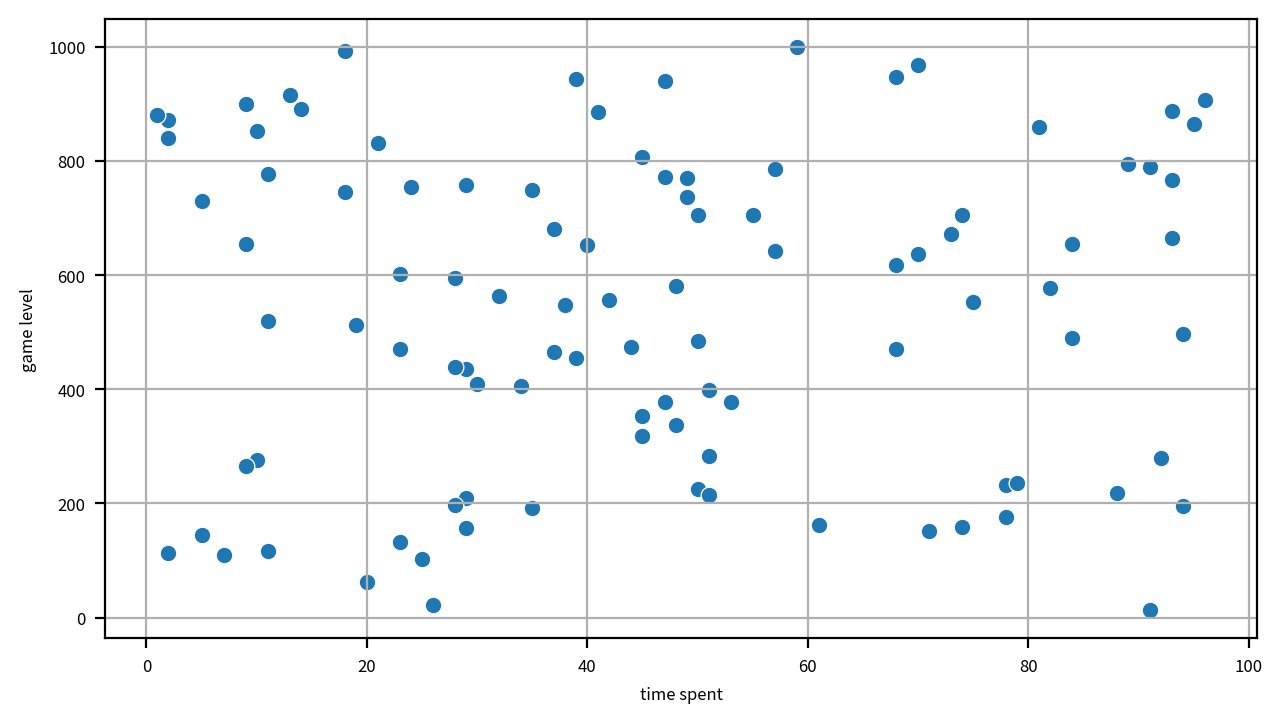

In [4]:
width_px = 1280
height_px = 720
rows = 1
cols=1
figsize = (width_px /my_dpi, height_px/my_dpi)
fig, ax = plt.subplots(rows,cols,figsize=figsize, dpi=my_dpi)

# 그래프 그리기->seaborn 사용
sb.scatterplot(data=origin, x="time spent",y = "game level")
            

ax.grid()
plt.tight_layout()
plt.show()
plt.close()

## 머신러닝 학습시키기

In [5]:
# 모델 객체 생성
#  -> randome_state는 실행할 때마다 같은 결과가 나오도록 고정하는 용도
# 생략시 매 실행마다 결과가 달라짐
estimator = KMeans(n_clusters=4, random_state = 52)

# 모델 학습시킴
estimator.fit(origin)

# 예측
cluster_pred = estimator.predict(origin)
cluster_pred

array([1, 3, 1, 1, 2, 1, 0, 0, 2, 0, 1, 3, 2, 3, 1, 2, 1, 2, 1, 3, 3, 1,
       2, 3, 2, 1, 3, 2, 0, 3, 3, 1, 0, 2, 1, 3, 0, 2, 2, 1, 0, 1, 1, 3,
       1, 3, 1, 0, 1, 2, 0, 2, 2, 2, 0, 1, 2, 3, 1, 0, 2, 3, 3, 3, 0, 1,
       0, 2, 0, 3, 1, 0, 2, 2, 1, 2, 1, 1, 2, 3, 2, 3, 0, 1, 2, 3, 1, 0,
       2, 2, 1, 3, 0, 3, 1, 1, 0, 1, 2, 0], dtype=int32)

## 📝[2]결과를 보기 좋게 만들자

In [6]:
df = origin.copy()
df["그룹번호"] = cluster_pred
df

,time spent,game level,그룹번호
0,39,944,1
1,55,705,3
2,29,757,1
3,59,999,1
4,7,109,2
...,...,...,...
95,47,939,1
96,50,485,0
97,13,916,1
98,79,235,2


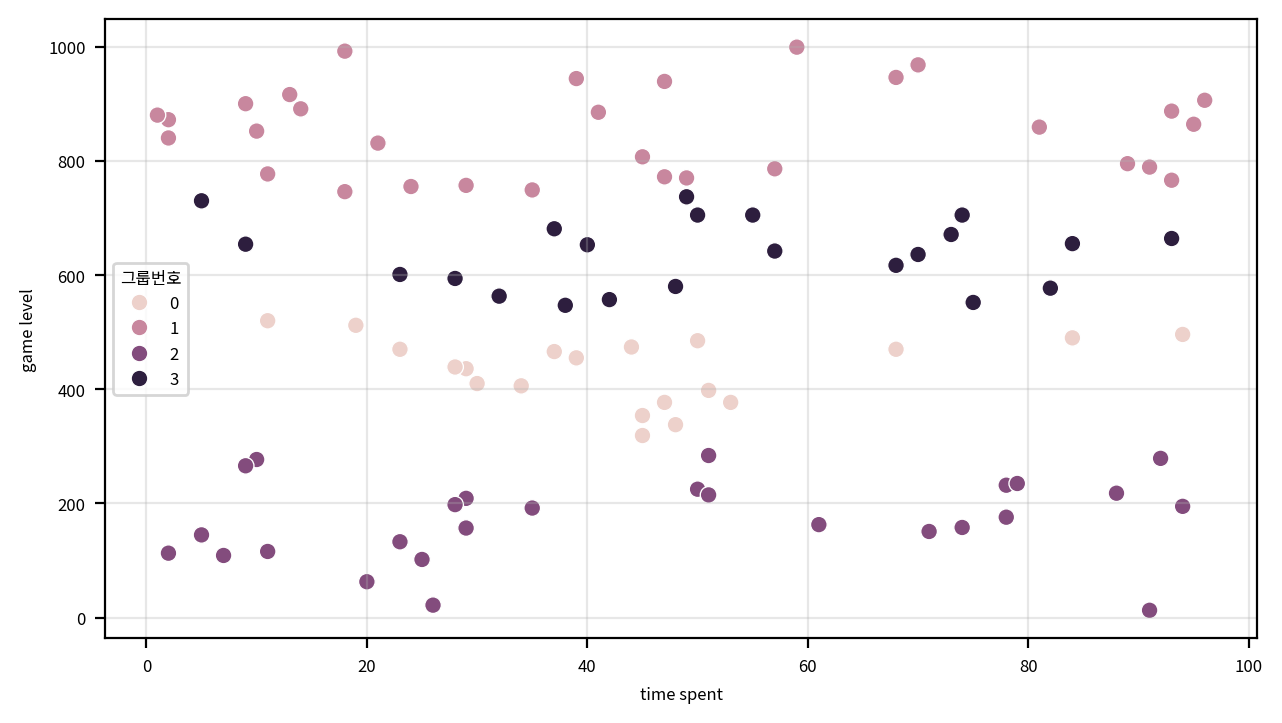

In [8]:
width_px = 1280
height_px = 720
rows = 1
cols=1
figsize = (width_px /my_dpi, height_px/my_dpi)
fig, ax = plt.subplots(rows,cols,figsize=figsize, dpi=my_dpi)

# 그래프 그리기->seaborn 사용
sb.scatterplot(data= df, x="time spent",y = "game level", hue = "그룹번호")
            

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

## 📝[4]결과 시각화(고급)

In [5]:
vdf = df.copy()
hue_field = "그룹번호"
x_field = "time spend"
y_field = "game level"

width_px = 1280
height_px = 720
rows = 1
cols=1
figsize = (width_px /my_dpi, height_px/my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize,dpi=my_dpi)

for c in vdf[hue_field].unique():

    # 값의 종류별로 데이터프레임을 나눔
    df_c = vdf.loc[vdf(hue_field)==c, [x_field, y_field]]

    try:
        hull = ConvexHull(df_c)
        points = np.append(hull.vertices, hull.vertices[0]) 
        # 시작점과 끝점을 연결

        ax.plot(
            df_c.iloc[points,0], df_c.iloc[points,1], linewidth = 0.5, linestyle =":"
        )

        ax.fill(df_c.iloc[points,0] , [df_c.iloc[points,1] ,alpha=0.1])

    except:
        pass

# 그래프 그리기->seaborn 사용
sb.scatterplot(data=vdf, x="x_field", y = "y_field", hue = hue_field)
            

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()


SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (360886784.py, line 27)

## 📝[1]표준화 되지 않은 원본 데이터를 x와 y축에 대하여 같은 범위로 설정하고 시각화

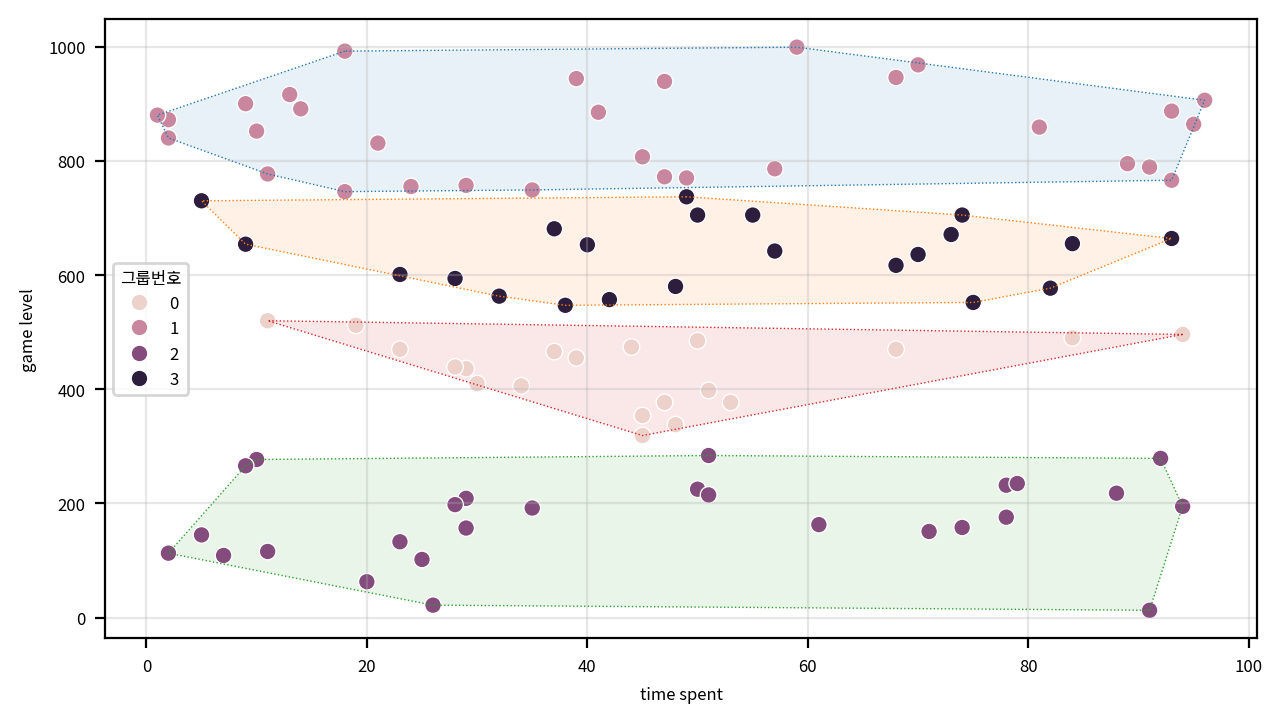

In [34]:
# 데이터 및 컬럼 설정
vdf = df.copy()

hue_field = "그룹번호"
x_field = "time spent"
y_field = "game level"


# -------------------------------
# 그래프 초기화
# -------------------------------
width_px = 1280   # 그래프 가로 크기
height_px = 720   # 그래프 세로 크기

rows = 1          # 그래프 행 수
cols = 1          # 그래프 열 수

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(
    rows,
    cols,
    figsize=figsize,
    dpi=my_dpi
)


# -------------------------------
# 군집별 Convex Hull 시각화
# -------------------------------
for c in vdf[hue_field].unique():

    # 군집별 데이터프레임 분리
    df_c = vdf.loc[
        vdf[hue_field] == c,
        [x_field, y_field]
    ]

    try:
        # 외곽선 좌표 계산
        hull = ConvexHull(df_c)

        # 마지막 좌표 이후 첫 번째 좌표 연결
        points = np.append(
            hull.vertices,
            hull.vertices[0]
        )

        # 외곽선 그리기
        ax.plot(
            df_c.iloc[points, 0],
            df_c.iloc[points, 1],
            linewidth=0.5,
            linestyle=":"
        )

        # 영역 채우기
        ax.fill(
            df_c.iloc[points, 0],
            df_c.iloc[points, 1],
            alpha=0.1
        )

    except Exception:
        pass


# -------------------------------
# 전체 산점도
# -------------------------------
sb.scatterplot(
    data=vdf,
    x=x_field,
    y=y_field,
    hue=hue_field
)


# -------------------------------
# 그래프 옵션 및 출력
# -------------------------------
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()     # 그래프 화면 출력
plt.close()    # 그래프 작업 종료


## 📝[2]데이터 스케일링에 대한 군집화

✏️(1)Standard Scaler

In [36]:
scaler = StandardScaler()
sdf = DataFrame(scaler.fit_transform(origin), columns=origin.columns)
sdf

,time spent,game level
0,-0.250733,1.474805
1,0.326494,0.606546
2,-0.611500,0.795456
3,0.470801,1.674613
4,-1.405187,-1.558652
...,...,...
95,0.037881,1.456640
96,0.146111,-0.192688
97,-1.188727,1.373084
98,1.192335,-1.100909


In [ ]:
estimator = KMeans(n_cluster=4)
# 모델 객체 생성
estimator.fit(sdf)
cluster = estimator.predict(sdf)
# 예측
sdf["그룹번호"] = cluster
sdf

In [ ]:
# 데이터 복사 및 컬럼 설정
vdf = sdf.copy()

hue_field = "그룹번호"
x_field = "time spent"
y_field = "game level"


# -------------------------------
# 그래프 초기화
# -------------------------------
width_px = 1280   # 그래프 가로 크기
height_px = 720   # 그래프 세로 크기

rows = 1          # 그래프 행 수
cols = 1          # 그래프 열 수

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(
    rows,
    cols,
    figsize=figsize,
    dpi=my_dpi
)


# -------------------------------
# 군집별 Convex Hull 시각화
# -------------------------------
for c in vdf[hue_field].unique():

    # 군집별 데이터프레임 분리
    df_c = vdf.loc[
        vdf[hue_field] == c,
        [x_field, y_field]
    ]

    try:
        # 외곽선 좌표 계산
        hull = ConvexHull(df_c)

        # 마지막 좌표 이후 첫 번째 좌표 연결
        points = np.append(
            hull.vertices,
            hull.vertices[0]
        )

        # 외곽선 그리기
        ax.plot(
            df_c.iloc[points, 0],
            df_c.iloc[points, 1],
            linewidth=0.5,
            linestyle=":"
        )

        # 영역 채우기
        ax.fill(
            df_c.iloc[points, 0],
            df_c.iloc[points, 1],
            alpha=0.1
        )

    except Exception:
        pass


# -------------------------------
# 전체 산점도
# -------------------------------
sb.scatterplot(
    data=vdf,
    x=x_field,
    y=y_field,
    hue=hue_field
)


# -------------------------------
# 그래프 옵션 및 출력
# -------------------------------
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()     # 그래프 화면 출력
plt.close()    # 그래프 작업 종료


## ✏️MinMax Scaler

In [ ]:
# -------------------------------
# 스케일링
# -------------------------------
scaler = MinMaxScaler()
mdf = DataFrame(
    scaler.fit_transform(origin),
    columns=origin.columns
)

# -------------------------------
# 모델 객체 생성
# -------------------------------
estimator = KMeans(n_clusters=4)

# -------------------------------
# 모델 학습
# -------------------------------
estimator.fit(mdf)

# -------------------------------
# 예측 및 결과 저장
# -------------------------------
cluster = estimator.predict(mdf)
mdf["그룹번호"] = cluster


# -------------------------------
# 시각화용 데이터 설정
# -------------------------------
vdf = mdf.copy()

hue_field = "그룹번호"
x_field = "time spent"
y_field = "game level"


# -------------------------------
# 그래프 초기화
# -------------------------------
width_px = 1280   # 그래프 가로 크기
height_px = 720   # 그래프 세로 크기

rows = 1          # 그래프 행 수
cols = 1          # 그래프 열 수

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(
    rows,
    cols,
    figsize=figsize,
    dpi=my_dpi
)


# -------------------------------
# 군집별 Convex Hull 시각화
# -------------------------------
for c in vdf[hue_field].unique():

    # 군집별 데이터프레임 분리
    df_c = vdf.loc[
        vdf[hue_field] == c,
        [x_field, y_field]
    ]

    try:
        # 외곽선 좌표 계산
        hull = ConvexHull(df_c)

        # 마지막 좌표 이후 첫 번째 좌표 연결
        points = np.append(
            hull.vertices,
            hull.vertices[0]
        )

        # 외곽선 그리기
        ax.plot(
            df_c.iloc[points, 0],
            df_c.iloc[points, 1],
            linewidth=0.5,
            linestyle=":"
        )

        # 영역 채우기
        ax.fill(
            df_c.iloc[points, 0],
            df_c.iloc[points, 1],
            alpha=0.1
        )

    except Exception:
        pass


# -------------------------------
# 전체 산점도
# -------------------------------
sb.scatterplot(
    data=vdf,
    x=x_field,
    y=y_field,
    hue=hue_field
)


# -------------------------------
# 그래프 옵션 및 출력
# -------------------------------
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()     # 그래프 화면 출력
plt.close()    # 그래프 작업 종료
